### Visinhos de um pixel

Você pode se perguntar: "Ok, mas para que serve isso?". Esses conceitos são a base para:
1. Filtros de Imagem: 
    - Um filtro de "blur" (borrão), por exemplo, pode substituir o valor do pixel p pela média dos valores de seus vizinhos N8.
2. Detecção de Bordas: 
    - Uma borda é detectada quando o valor de p é drasticamente diferente dos valores de seus vizinhos.
3. Segmentação de Imagens: 
    - Para agrupar todos os pixels que formam um objeto, o computador precisa "andar" de pixel em pixel. Ele usa as regras de vizinhança para saber para onde pode ir. Se ele só pode andar para os vizinhos N4, dizemos que estamos usando "conectividade-4". Se pode andar para os N8, usamos "conectividade-8".

In [5]:
import numpy as np

# Vamos criar uma imagem 5x5 com valores de 0 a 24 para facilitar a visualização
imagem_exemplo = np.arange(25).reshape(5, 5)

# Nosso pixel de interesse 'p' está na coordenada (x=2, y=2)
# Lembre-se que em programação, a contagem começa do 0.
x, y = 2, 2
pixel_p = imagem_exemplo[y, x]

print("--- Imagem Exemplo ---")
print(imagem_exemplo)
print(f"\nNosso pixel 'p' está em ({x}, {y}) e tem o valor: {pixel_p}\n")

# --- Encontrando a Vizinhança-4 (N4) ---
# Coordenadas: (x-1,y), (x+1,y), (x,y-1), (x,y+1)
n4_coords = [(y-1, x), (y+1, x), (y, x-1), (y, x+1)]
n4_valores = [imagem_exemplo[coord] for coord in n4_coords]

print("--- Vizinhança-4 (N4) de p ---")
print(f"Coordenadas: {n4_coords}")
print(f"Valores: {n4_valores}")

# --- Encontrando a Vizinhança Diagonal (ND) ---
# Coordenadas: (x-1,y-1), (x-1,y+1), (x+1,y-1), (x+1,y+1)
nd_coords = [(y-1, x-1), (y-1, x+1), (y+1, x-1), (y+1, x+1)]
nd_valores = [imagem_exemplo[coord] for coord in nd_coords]

print("\n--- Vizinhança Diagonal (ND) de p ---")
print(f"Coordenadas: {nd_coords}")
print(f"Valores: {nd_valores}")

# --- Encontrando a Vizinhança-8 (N8) ---
n8_coords = n4_coords + nd_coords
n8_valores = n4_valores + nd_valores

print("\n--- Vizinhança-8 (N8) de p ---")
print(f"Coordenadas: {n8_coords}")
print(f"Valores: {n8_valores}")

--- Imagem Exemplo ---
[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]

Nosso pixel 'p' está em (2, 2) e tem o valor: 12

--- Vizinhança-4 (N4) de p ---
Coordenadas: [(1, 2), (3, 2), (2, 1), (2, 3)]
Valores: [np.int64(7), np.int64(17), np.int64(11), np.int64(13)]

--- Vizinhança Diagonal (ND) de p ---
Coordenadas: [(1, 1), (1, 3), (3, 1), (3, 3)]
Valores: [np.int64(6), np.int64(8), np.int64(16), np.int64(18)]

--- Vizinhança-8 (N8) de p ---
Coordenadas: [(1, 2), (3, 2), (2, 1), (2, 3), (1, 1), (1, 3), (3, 1), (3, 3)]
Valores: [np.int64(7), np.int64(17), np.int64(11), np.int64(13), np.int64(6), np.int64(8), np.int64(16), np.int64(18)]


### 2.5.2 Adjacência, conectividade, regiões e fronteiras

Colocando em Prática: O Exemplo da Ambiguidade

Vamos recriar a situação da Figura 2.25(a, b, c) para entender a Adjacência-m.

In [6]:
import numpy as np

# Recriando o arranjo da Figura 2.25(a)
# V = {1}
arranjo = np.array([[0, 1, 1],
                    [0, 1, 0],
                    [0, 0, 1]])

# Vamos analisar a conexão entre p=(0,1) [valor 1] e q=(1,2) [valor 0] - não são adjacentes
# Vamos analisar a conexão entre p=(0,1) [valor 1] e q=(1,1) [valor 1]
p = (0, 1)
q = (1, 1)
print("--- Analisando o arranjo da Figura 2.25 ---")
print(arranjo)
print(f"\nAnalisando a adjacência entre p em {p} e q em {q}")


# Adjacência-8: q está na vizinhança N8(p)? Sim. Os valores de p e q são 1? Sim.
# Conclusão: p e q SÃO adjacentes-8.

# Agora, o caso da ambiguidade, entre p=(0,2) e q=(1,1)
p_ambiguo = (0, 2)
q_ambiguo = (1, 1)

print(f"\nAnalisando a adjacência ambígua entre p em {p_ambiguo} e q em {q_ambiguo}")

# Adjacência-m:
# 1. q está em N4(p)? Não.
# 2. q está em ND(p)? Sim.
# 3. Agora a condição extra: os vizinhos em comum N4(p) e N4(q) são os pixels (0,1) e (1,2)
vizinhos_comuns_coords = [(0, 1), (1, 2)]
# Vamos ver os valores deles
valor_vizinho1 = arranjo[0, 1]
valor_vizinho2 = arranjo[1, 2]
print(f"Vizinhos em comum têm valores: {valor_vizinho1} e {valor_vizinho2}")

# A condição é: NENHUM deles pode pertencer a V={1}.
# Mas o vizinho (0,1) tem valor 1, que pertence a V.
# Portanto, a condição (ii) FALHA.
print("Conclusão: p e q NÃO SÃO adjacentes-m.")

# Isso quebra a ambiguidade da "escada" que a adjacência-8 permite.

--- Analisando o arranjo da Figura 2.25 ---
[[0 1 1]
 [0 1 0]
 [0 0 1]]

Analisando a adjacência entre p em (0, 1) e q em (1, 1)

Analisando a adjacência ambígua entre p em (0, 2) e q em (1, 1)
Vizinhos em comum têm valores: 1 e 0
Conclusão: p e q NÃO SÃO adjacentes-m.


Conceito 3: Conectividade, Regiões e Fronteiras

Agora que temos as "estradas" (adjacência), podemos definir conceitos maiores.
- Caminho (Path): É uma sequência de pixels que vai de `p` até `q`, onde cada passo na sequência é para um pixel adjacente (usando uma das 3 regras: 4, 8 ou m). Pense numa rota de GPS.

- Conexo (Connected): Dois pixels p e q são conexos se existe um caminho entre eles formado inteiramente por pixels da nossa lista V. Se você pode viajar de uma cidade a outra sem sair do país, elas são cidades "conexas".

- Região (Region): É um conjunto de pixels onde todos são conexos entre si.  Em nossa analogia, isso é um país inteiro. Todos os pixels (cidades) dentro dele são alcançáveis a partir de qualquer outro. O livro também chama de componente conexo. 

- Fronteira (Boundary): É o conjunto de pixels de uma região que são "vizinhos do inimigo".
    - A Regra Simples: Um pixel p está na fronteira de uma região R se:
        1. p pertence à região R.
        1. p tem pelo menos um vizinho que NÃO pertence a R (está no fundo).

Exemplo Prático Final: Encontrando Regiões e Fronteiras

Vamos pegar uma imagem com alguns "objetos" e usar o OpenCV para aplicar esses conceitos de forma visual. O OpenCV tem funções que fazem todo esse trabalho pesado para nós!

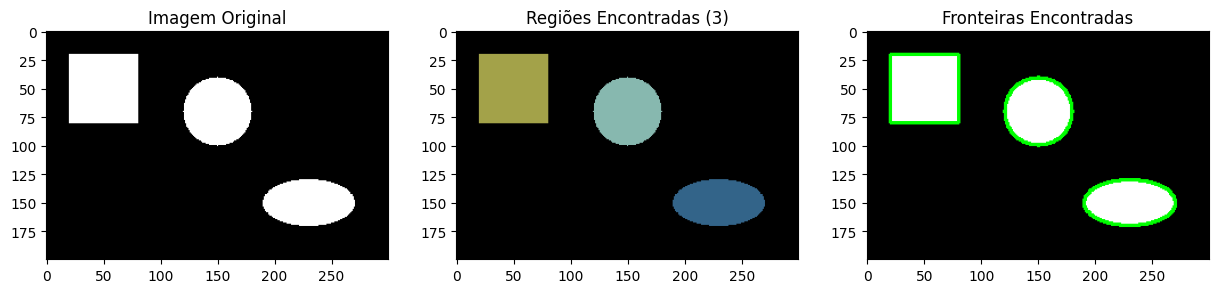

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Criar uma imagem binária com alguns objetos (nossas futuras 'regiões')
imagem = np.zeros((200, 300), dtype=np.uint8)
# V = {255} (branco)
cv2.rectangle(imagem, (20, 20), (80, 80), 255, -1)
cv2.circle(imagem, (150, 70), 30, 255, -1)
cv2.ellipse(imagem, (230, 150), (40, 20), 0, 0, 360, 255, -1)

# 2. Encontrar os Componentes Conexos (as Regiões)
# A função cv2.connectedComponentsWithStats encontra todos os "países" na imagem.
# Ela usa adjacência-8 por padrão.
num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(imagem, connectivity=8)

# Para visualizar, vamos criar uma imagem colorida onde cada região tem uma cor.
imagem_regioes = np.zeros((imagem.shape[0], imagem.shape[1], 3), dtype=np.uint8)
# Gerar cores aleatórias para cada rótulo (exceto o fundo, que é 0)
for i in range(1, num_labels):
    imagem_regioes[labels_im == i] = np.random.randint(50, 255, size=3).tolist()

# 3. Encontrar as Fronteiras (Contornos)
# A função cv2.findContours encontra as fronteiras das regiões.
contours, hierarchy = cv2.findContours(imagem, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Desenhar os contornos em uma nova imagem
imagem_fronteiras = cv2.cvtColor(imagem, cv2.COLOR_GRAY2BGR)
cv2.drawContours(imagem_fronteiras, contours, -1, (0, 255, 0), 2) # Desenha em verde


# Exibindo tudo
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(imagem, cmap='gray'), plt.title('Imagem Original')
plt.subplot(1, 3, 2), plt.imshow(imagem_regioes), plt.title(f'Regiões Encontradas ({num_labels-1})')
plt.subplot(1, 3, 3), plt.imshow(imagem_fronteiras), plt.title('Fronteiras Encontradas')
plt.show()

---

Visualizando

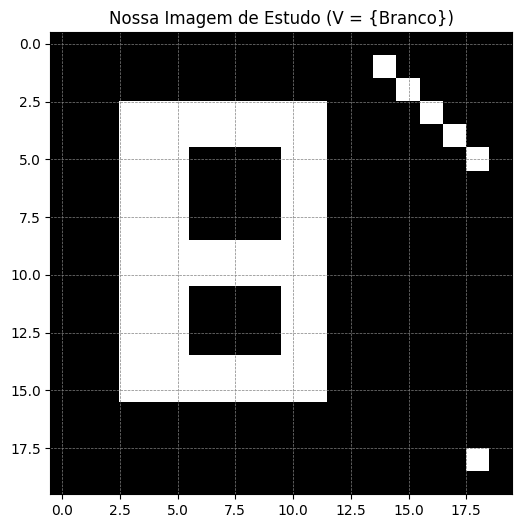

In [8]:
# Importando as bibliotecas que vamos usar
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Criando nossa imagem de estudo (20x20 pixels) ---
# V = {255} (nosso "time" é o dos pixels brancos)
img = np.zeros((20, 20), dtype=np.uint8)

# Desenhando uma letra 'B' para ter regiões com "buracos"
img[3:16, 3:6] = 255
img[3:5, 3:12] = 255
img[9:11, 3:12] = 255
img[14:16, 3:12] = 255
img[5:9, 10:12] = 255
img[11:14, 10:12] = 255

# Desenhando uma linha diagonal para testar a conectividade
for i in range(5):
    img[i+1, i+14] = 255

# Desenhando um ponto isolado
img[18, 18] = 255

# --- Exibindo nossa imagem de estudo ---
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray', interpolation='nearest')
plt.title('Nossa Imagem de Estudo (V = {Branco})')
plt.grid(True, color='gray', linestyle='--', linewidth=0.5)
plt.show()

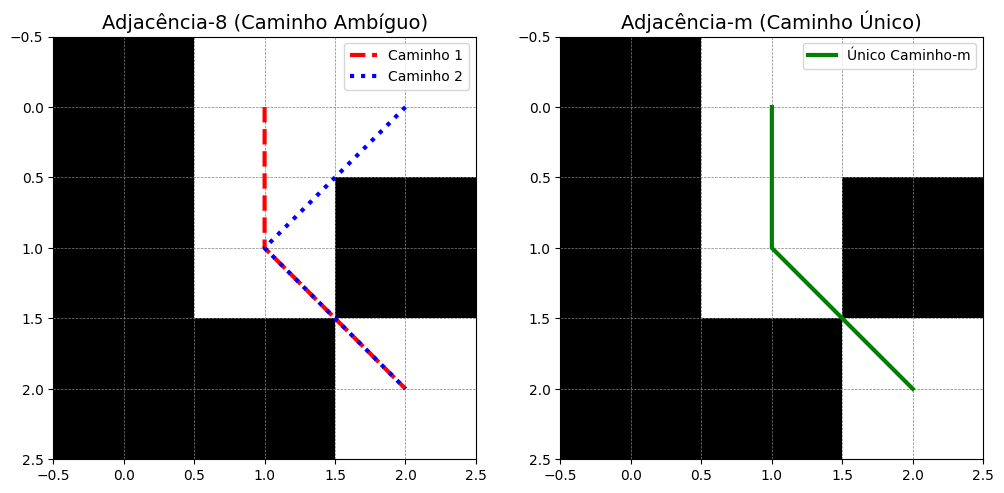

In [9]:
# --- Criando o padrão da Figura 2.25(a) ---
arranjo = np.array([[0, 255, 255],
                    [0, 255, 0],
                    [0, 0, 255]])

# Posições dos pixels da "escada"
p1, p2, p3, p4 = (0,1), (0,2), (1,1), (2,2)

# --- Visualização ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Adjacência-8 (Ambiguidade)
ax1.imshow(arranjo, cmap='gray', interpolation='nearest')
ax1.set_title('Adjacência-8 (Caminho Ambíguo)', fontsize=14)
ax1.grid(True, color='gray', linestyle='--', linewidth=0.5)
# Desenhando os dois caminhos possíveis
ax1.plot([p1[1], p3[1], p4[1]], [p1[0], p3[0], p4[0]], 'r--', linewidth=3, label='Caminho 1')
ax1.plot([p2[1], p3[1], p4[1]], [p2[0], p3[0], p4[0]], 'b:', linewidth=3, label='Caminho 2')
ax1.legend()


# Adjacência-m (Sem Ambiguidade)
ax2.imshow(arranjo, cmap='gray', interpolation='nearest')
ax2.set_title('Adjacência-m (Caminho Único)', fontsize=14)
ax2.grid(True, color='gray', linestyle='--', linewidth=0.5)
# A conexão entre (0,2) e (1,1) é quebrada. Só um caminho resta.
ax2.plot([p1[1], p3[1], p4[1]], [p1[0], p3[0], p4[0]], 'g-', linewidth=3, label='Único Caminho-m')
ax2.legend()

plt.show()

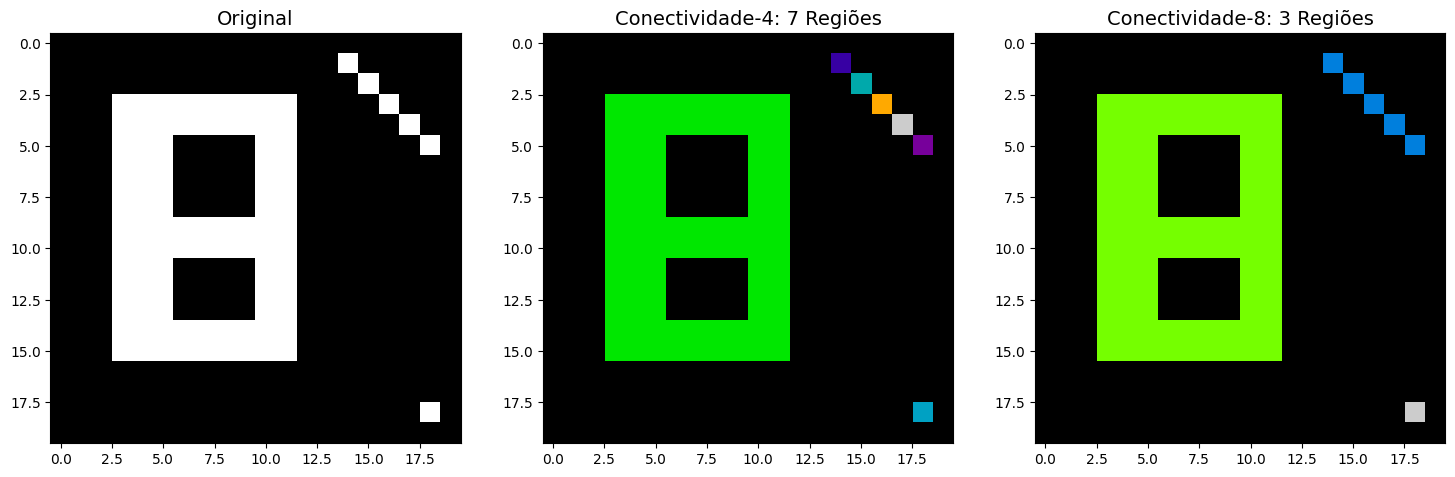

In [10]:
# --- Encontrando Regiões com Conectividade-4 ("Estradas Retas") ---
num_labels_4, labels_4 = cv2.connectedComponents(img, connectivity=4)
img_regioes_4 = np.zeros_like(img, dtype=np.uint8)
for i in range(1, num_labels_4):
    img_regioes_4[labels_4 == i] = (i * 50) % 255 # Colore cada região
img_regioes_4[img_regioes_4 == 0] = 20 # Cor de fundo para destacar


# --- Encontrando Regiões com Conectividade-8 ("Estradas Retas e Diagonais") ---
num_labels_8, labels_8 = cv2.connectedComponents(img, connectivity=8)
img_regioes_8 = np.zeros_like(img, dtype=np.uint8)
for i in range(1, num_labels_8):
    img_regioes_8[labels_8 == i] = (i * 70) % 255 # Colore cada região
img_regioes_8[img_regioes_8 == 0] = 20 # Cor de fundo


# --- Visualização Comparativa ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray', interpolation='nearest')
ax1.set_title('Original', fontsize=14)

ax2.imshow(img_regioes_4, cmap='nipy_spectral', interpolation='nearest')
ax2.set_title(f'Conectividade-4: {num_labels_4 - 1} Regiões', fontsize=14)

ax3.imshow(img_regioes_8, cmap='nipy_spectral', interpolation='nearest')
ax3.set_title(f'Conectividade-8: {num_labels_8 - 1} Regiões', fontsize=14)

plt.show()

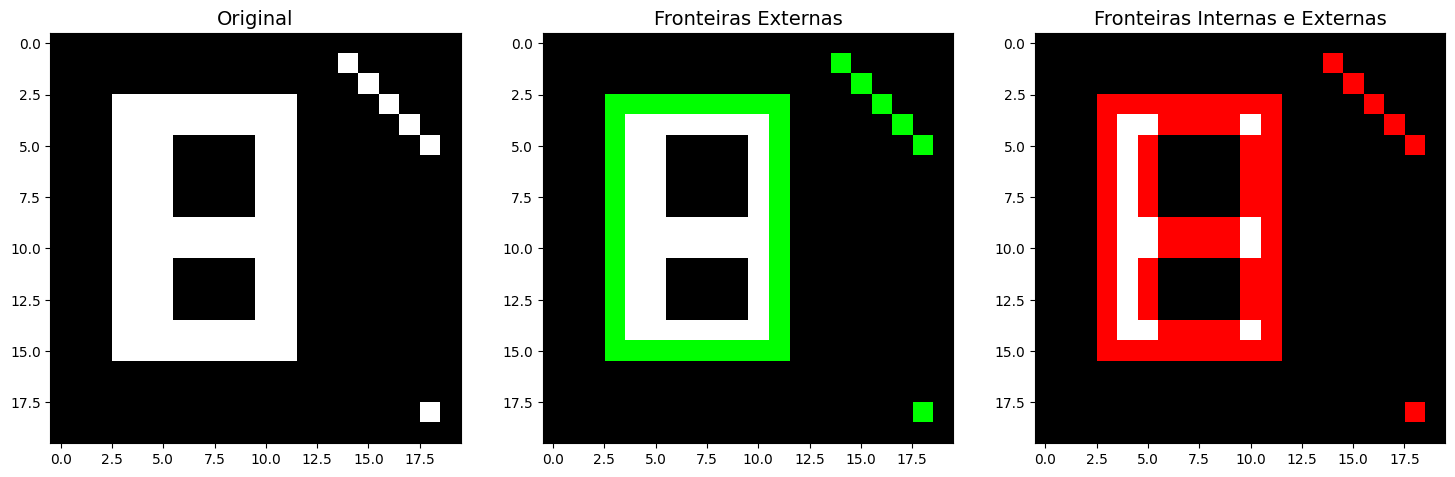

In [11]:
# --- Encontrando as Fronteiras ---
# Usamos a conectividade-8 que é mais comum para essa tarefa

# 1. Fronteiras Externas: Ignora os buracos
contours_ext, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_fronteira_ext = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_fronteira_ext, contours_ext, -1, (0, 255, 0), 1) # Verde

# 2. Fronteiras Externas E Internas: Encontra os buracos também
contours_all, _ = cv2.findContours(img, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
img_fronteira_all = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_fronteira_all, contours_all, -1, (255, 0, 0), 1) # Vermelho


# --- Visualização ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray', interpolation='nearest')
ax1.set_title('Original', fontsize=14)

ax2.imshow(img_fronteira_ext)
ax2.set_title('Fronteiras Externas', fontsize=14)

ax3.imshow(img_fronteira_all)
ax3.set_title('Fronteiras Internas e Externas', fontsize=14)

plt.show()